# ⚠️ DEPRECATED — diag-Shampoo protagonist (frozen)

Superseded by `paper_plots.ipynb` (the current kl-diag notebook) (2026-06-11 pivot: diag-Shampoo → KL-diag, β₁=0.9, gram_ns inverse-sqrt). **Kept only as the justification record**: the 8B curvature-lever probe, the kl-diag≡diag 1B sanity gate, and the β-select cells below are why the pivot was made (see `docs/notes/kl_diag_pivot.md`). Do not edit.

---

# Paper plots / experiment tracker

Live figures from the experiment logs (see `paper/PLAN.md`, `paper/e1_coverage_fill.md`).
Baselines are **AdamW + iMuon only**. Each panel: AdamW vs Polar-LoRA (diag-Shampoo) vs iMuon,
Δ vs AdamW in σ-units. Renders partially as runs land (`allow_partial=True`). One plot per
cell. Re-run top-to-bottom to refresh.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lora_playground').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lora_playground.plotting import compare_variants_figure
from lora_playground.loader import load_runs

# Baselines + protagonist. AdamW MUST be a variant to render (target_label only annotates
# an already-loaded variant, it does not auto-load).
ADAMW = {'optimizer': 'adamw'}
PROTO = {'optimizer': 'diag-shampoo-polar-lora', 'cw_nesterov': True, 'polar_method': 'polar_express',
         'cw_no_radius': False, 'cw_no_diag_curv': False}  # full method (excludes E2 ablation arms)
# E2 leave-one-out arms (same optimizer; disambiguated by the cw_no_* flags so they
# do NOT contaminate the protagonist panels above):
NOSHAMPOO = {**PROTO, 'cw_no_diag_curv': True}   # -Shampoo: partner-Gram only = iMuon + radius
NORADIUS  = {**PROTO, 'cw_no_radius':   True}    # -radius: plain eta (no operator-norm radius)

def _om(rank):  # common_where for Llama-openmath at a rank
    return dict(model_name='meta-llama/Llama-3.2-1B', lora_r=rank, data_dir=(lambda d: 'openmath' in str(d)))
def _has(where, rank):
    return len(load_runs(where={**where, **{k:v for k,v in _om(rank).items()}}, warn_cross_commit=False)) > 0
def ablation_panel(rank):
    """E2 leave-one-out at one rank; only arms with data render (allow_partial)."""
    arms = {'Polar-LoRA (diag-Shampoo)': PROTO, '-Shampoo (iMuon+radius)': NOSHAMPOO, '-radius (plain eta)': NORADIUS}
    arms = {k: v for k, v in arms.items() if _has(v, rank)}
    fig, _t, sdf = compare_variants_figure(
        arms, common_where=_om(rank), ref_label='Polar-LoRA (diag-Shampoo)',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True,
        suptitle=f'E2 ablation - Llama-3.2-1B openmath r{rank}')
    plt.show()
    return sdf
IMUON = {'optimizer': 'imuon-lora'}
SIGMA = 0.0017  # AdamW noise-floor proxy

# The 8-cell E1 set (paper/e1_coverage_fill.md). data_key = substring matched on data_dir.
CELLS = [
    ('OLMo-2-1B opc r256',         'allenai/OLMo-2-0425-1B',     'opc',      256),
    ('Qwen2.5-1.5B opc r256',      'Qwen/Qwen2.5-1.5B',          'opc',      256),
    ('Llama-3.2-1B opc r256',      'meta-llama/Llama-3.2-1B',    'opc',      256),
    ('Llama-3-8B opc r256',        'meta-llama/Meta-Llama-3-8B', 'opc',      256),
    ('Qwen2.5-1.5B bengali r256',  'Qwen/Qwen2.5-1.5B',          'bengali',  256),
    ('Llama-3.2-1B openmath r64',  'meta-llama/Llama-3.2-1B',    'openmath',  64),
    ('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B',    'openmath', 128),
    ('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B',    'openmath', 256),
]

def panel(name, model, key, rank):
    """AdamW vs Polar-LoRA (diag-Shampoo) vs iMuon at one cell; Δ vs AdamW in σ-units."""
    common = dict(model_name=model, lora_r=rank, data_dir=(lambda d, k=key: k in str(d)))
    fig, _tdf, sdf = compare_variants_figure(
        {'AdamW': ADAMW, 'Polar-LoRA (diag-Shampoo)': PROTO, 'iMuon': IMUON},
        common_where=common, ref_label='AdamW',
        logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
        allow_partial=True, allow_custom_labels=True, target_label='AdamW',
        suptitle=name,
    )
    plt.show()
    return sdf

## Coverage status (live)
Distinct lrs present per (cell, optimizer).

In [2]:
def _cfg(r):
    return r[0].get('_cli_args', r[0])

def _slug(c, key):
    return key in (str(c.get('data_dir', '')) + str(c.get('train_file', ''))).lower()

_cache = {opt: [ _cfg(x) for x in load_runs(where={'optimizer': opt}, warn_cross_commit=False) ]
          for opt in ('diag-shampoo-polar-lora', 'imuon-lora', 'adamw')}

def _nlrs(opt, model, key, rank, proto=False):
    lrs = set()
    for c in _cache[opt]:
        if c.get('model_name') == model and c.get('lora_r') == rank and _slug(c, key):
            if proto and not (c.get('cw_nesterov') and c.get('polar_method') == 'polar_express'):
                continue
            lrs.add(c.get('lr'))
    return len(lrs)

print(f"{'cell':28} | proto | iMuon | AdamW")
print('-' * 52)
for name, model, key, rank in CELLS:
    print(f"{name:28} | {_nlrs('diag-shampoo-polar-lora', model, key, rank, True):5d} | "
          f"{_nlrs('imuon-lora', model, key, rank):5d} | {_nlrs('adamw', model, key, rank):5d}")

cell                         | proto | iMuon | AdamW
----------------------------------------------------
OLMo-2-1B opc r256           |     3 |     0 |     5
Qwen2.5-1.5B opc r256        |     6 |     0 |     5
Llama-3.2-1B opc r256        |     6 |     0 |     5
Llama-3-8B opc r256          |     5 |     0 |     4
Qwen2.5-1.5B bengali r256    |     6 |     0 |     5
Llama-3.2-1B openmath r64    |     7 |     0 |     4
Llama-3.2-1B openmath r128   |     7 |     0 |     4
Llama-3.2-1B openmath r256   |     7 |     0 |     4


## Per-cell panels — AdamW vs Polar-LoRA (diag-Shampoo) vs iMuon

### 1. OLMo-2-1B opc r256

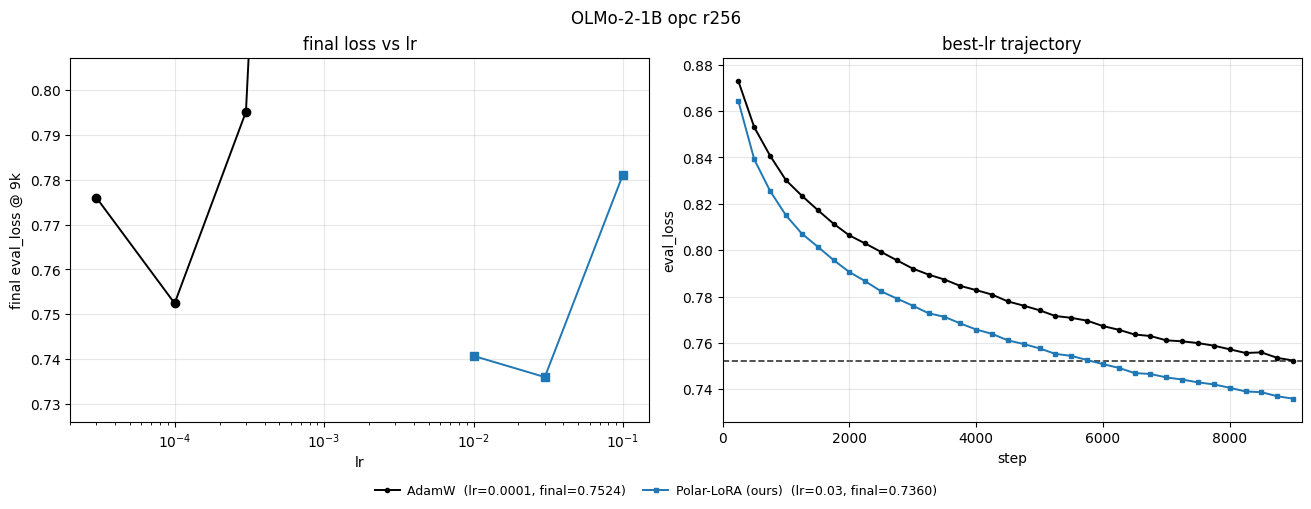

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.752439,NaN,NaN
1,Polar-LoRA (ours),0.0300,0.735985,-0.016454,-9.678906


In [3]:
panel('OLMo-2-1B opc r256', 'allenai/OLMo-2-0425-1B', 'opc', 256)

### 2. Qwen2.5-1.5B opc r256

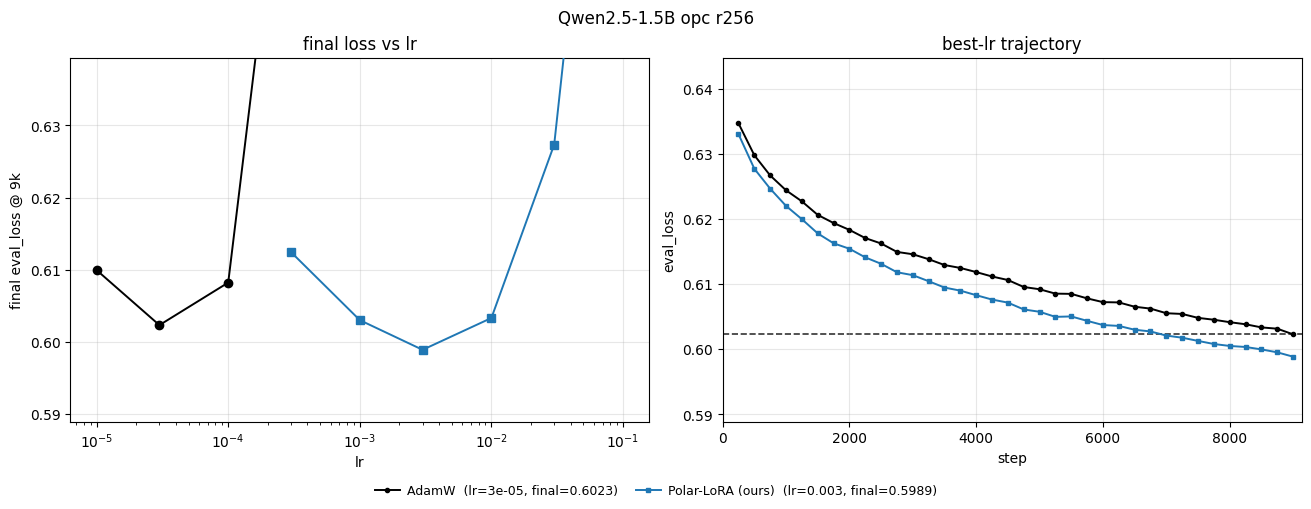

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.602292,NaN,NaN
1,Polar-LoRA (ours),0.00300,0.598864,-0.003427,-2.016134


In [4]:
panel('Qwen2.5-1.5B opc r256', 'Qwen/Qwen2.5-1.5B', 'opc', 256)

### 3. Llama-3.2-1B opc r256

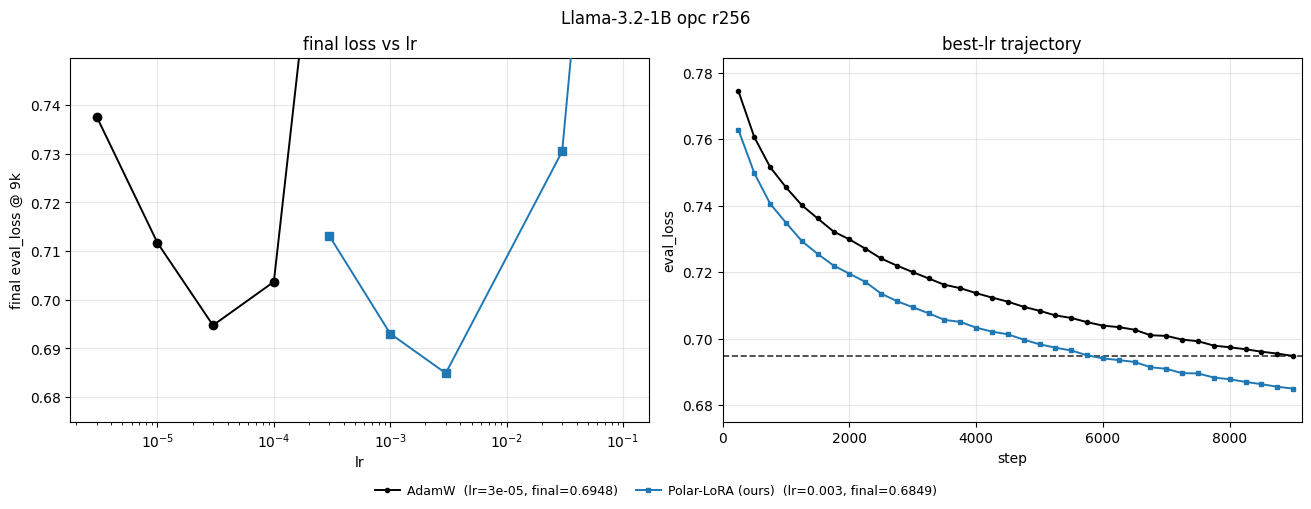

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.694754,NaN,NaN
1,Polar-LoRA (ours),0.00300,0.684921,-0.009833,-5.784146


In [5]:
panel('Llama-3.2-1B opc r256', 'meta-llama/Llama-3.2-1B', 'opc', 256)

### 4. Llama-3-8B opc r256

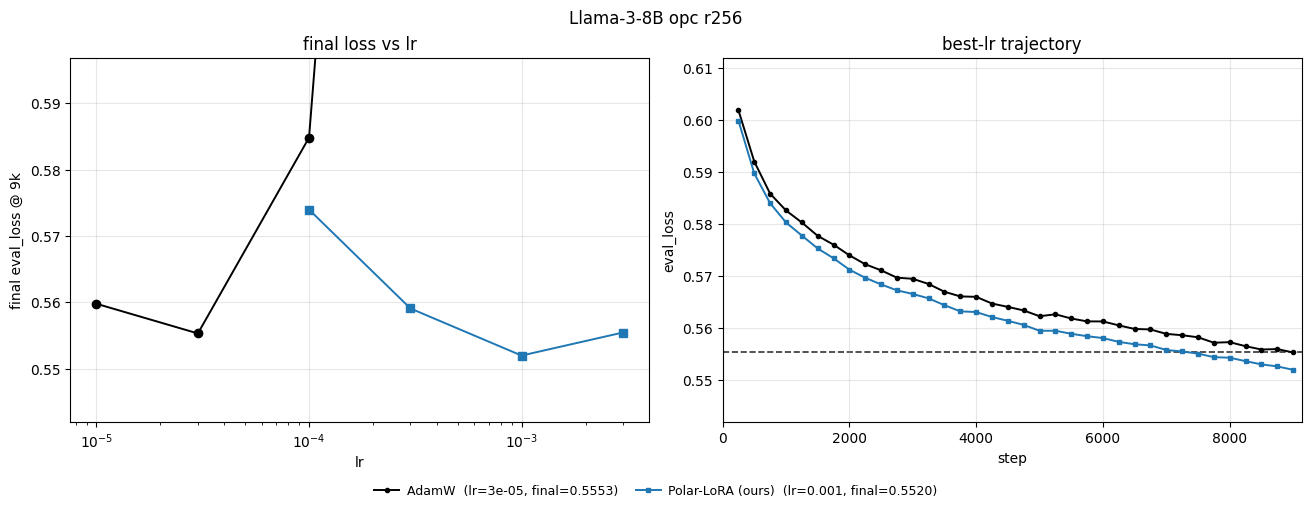

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,NaN,NaN
1,Polar-LoRA (ours),0.00100,0.551968,-0.003335,-1.961799


In [6]:
panel('Llama-3-8B opc r256', 'meta-llama/Meta-Llama-3-8B', 'opc', 256)

### 5. Qwen2.5-1.5B bengali r256  (OOD pair vs cell 2)

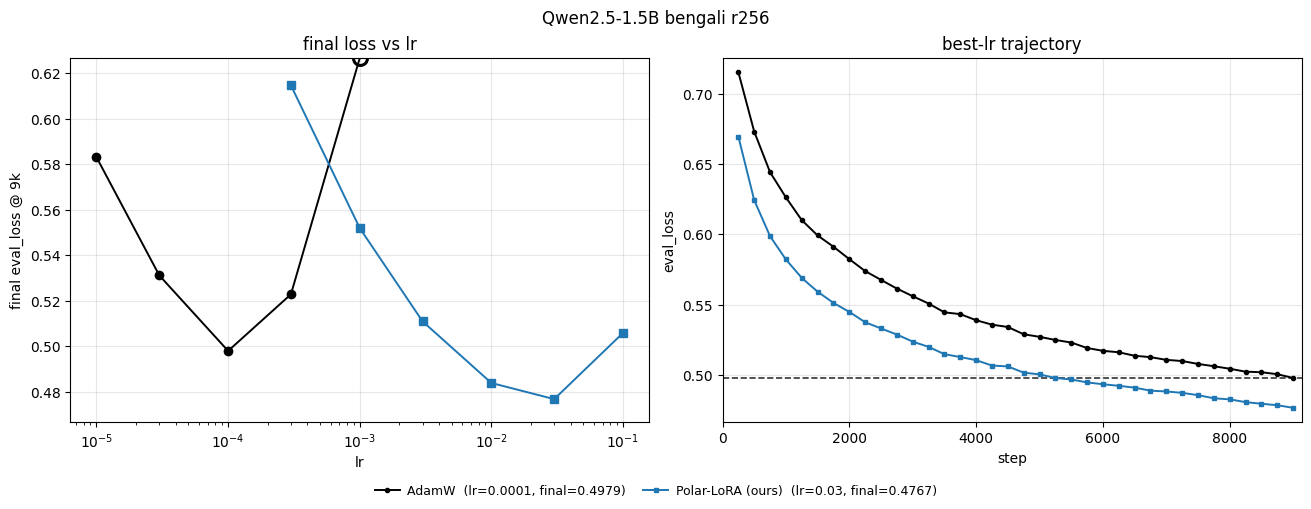

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.497858,NaN,NaN
1,Polar-LoRA (ours),0.0300,0.476662,-0.021196,-12.468087


In [7]:
panel('Qwen2.5-1.5B bengali r256', 'Qwen/Qwen2.5-1.5B', 'bengali', 256)

### 6. Llama-3.2-1B openmath r64  (rank ladder)

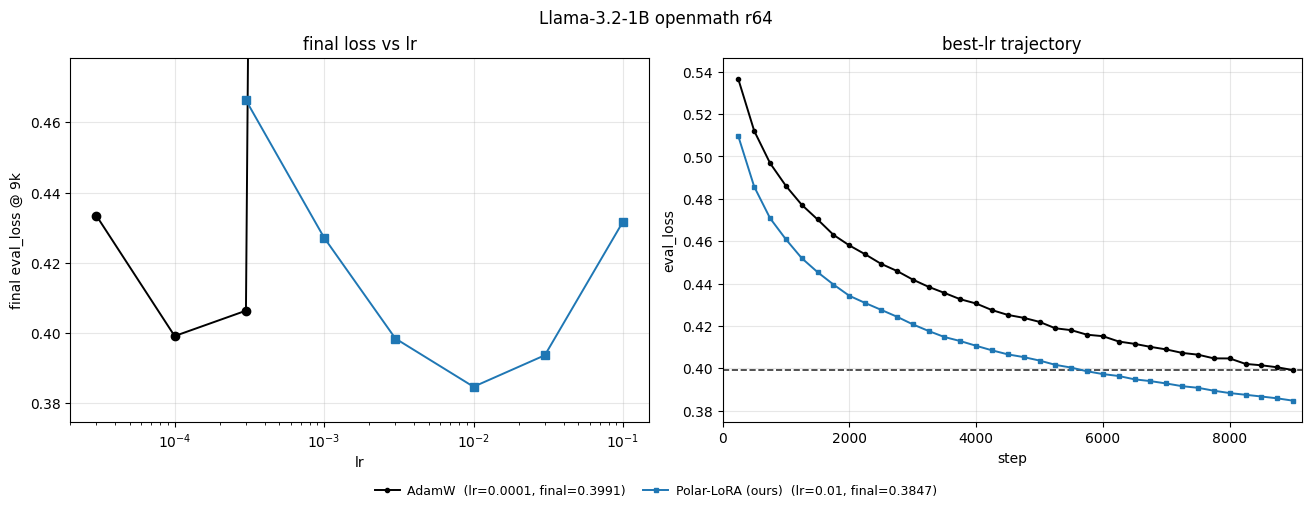

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.399128,NaN,NaN
1,Polar-LoRA (ours),0.0100,0.384694,-0.014434,-8.490744


In [8]:
panel('Llama-3.2-1B openmath r64', 'meta-llama/Llama-3.2-1B', 'openmath', 64)

### 7. Llama-3.2-1B openmath r128  (rank ladder)

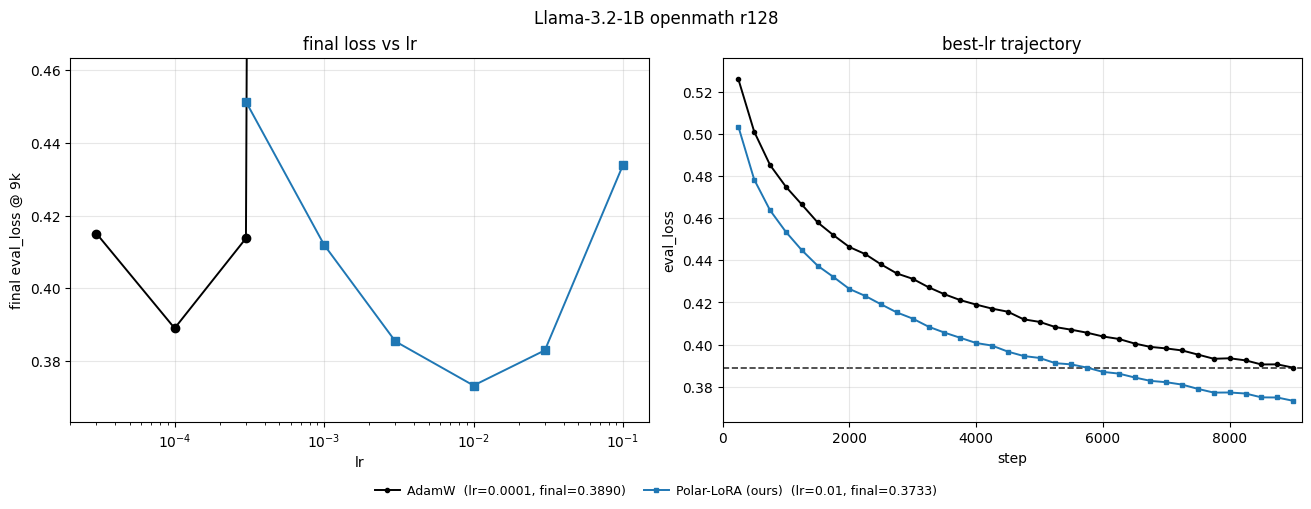

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.389044,NaN,NaN
1,Polar-LoRA (ours),0.0100,0.373298,-0.015746,-9.262494


In [9]:
panel('Llama-3.2-1B openmath r128', 'meta-llama/Llama-3.2-1B', 'openmath', 128)

### 8. Llama-3.2-1B openmath r256  (rank ladder)

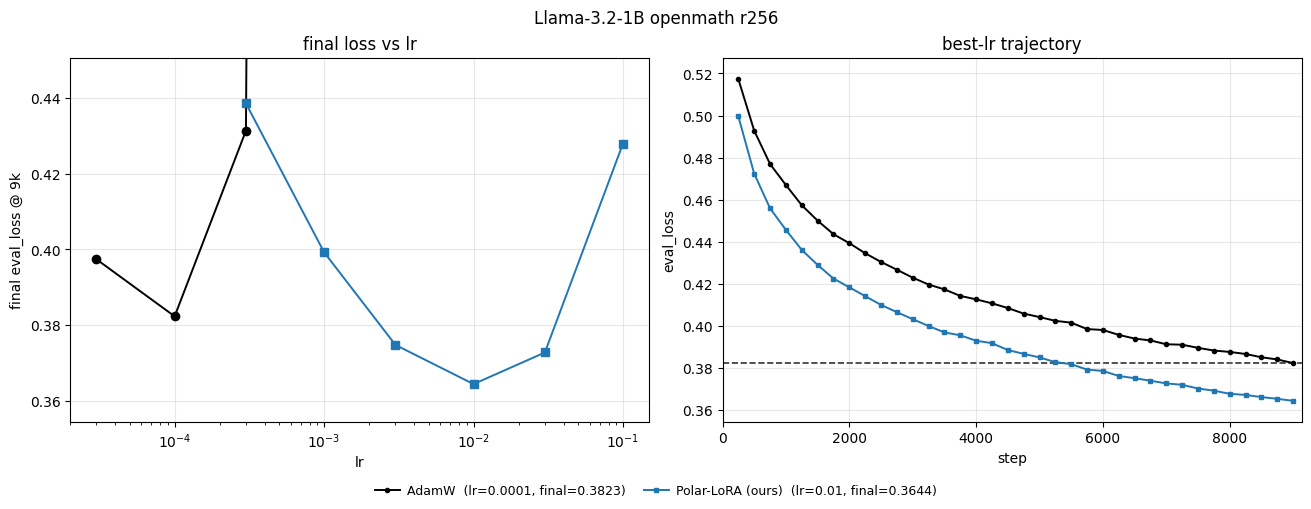

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.0001,0.382301,NaN,NaN
1,Polar-LoRA (ours),0.0100,0.364361,-0.017939,-10.552605


In [10]:
panel('Llama-3.2-1B openmath r256', 'meta-llama/Llama-3.2-1B', 'openmath', 256)

## E2 ablation — Llama-3.2-1B openmath, per rank (leave-one-out)

One panel per rank. Arms: **Polar-LoRA (diag-Shampoo)** vs **-Shampoo** (drop diagonal curvature -> iMuon+radius;
the novelty over iMuon) vs **-radius** (drop the operator-norm radius). Delta vs Polar-LoRA (diag-Shampoo) in
sigma-units, step-matched (`allow_partial`). -Shampoo was run only at r256; r64/r128 show the
arms that exist. Polar is *not* ablated (cited to the spectral-method literature).

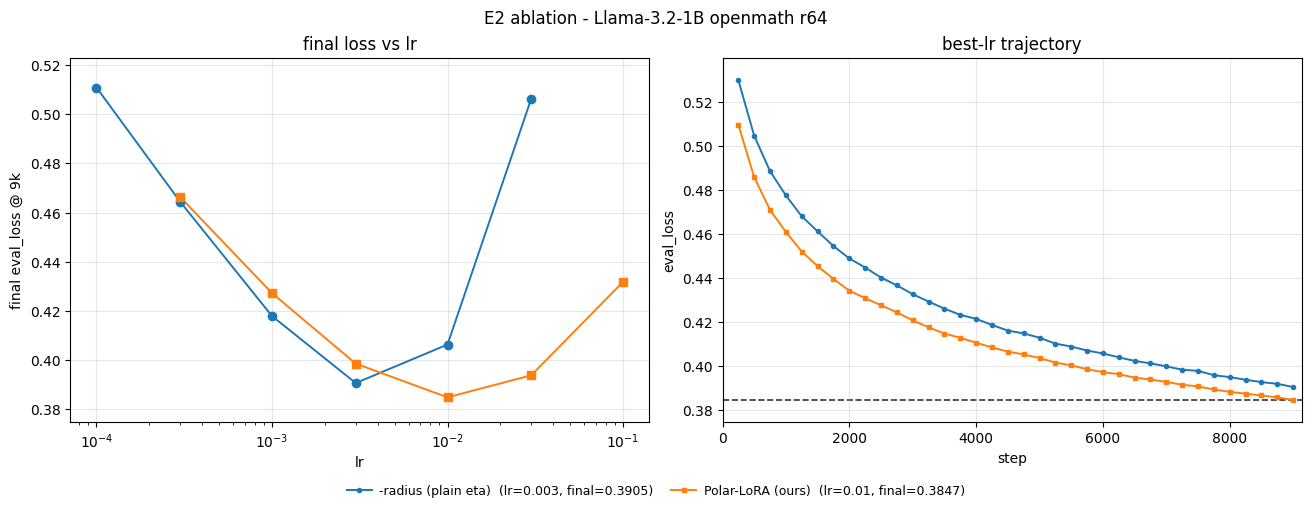

,variant,best_lr,final,delta,delta_sigma
0,-radius (plain eta),0.003,0.390512,0.005818,3.422303
1,Polar-LoRA (ours),0.010,0.384694,NaN,NaN


In [11]:
ablation_panel(64)

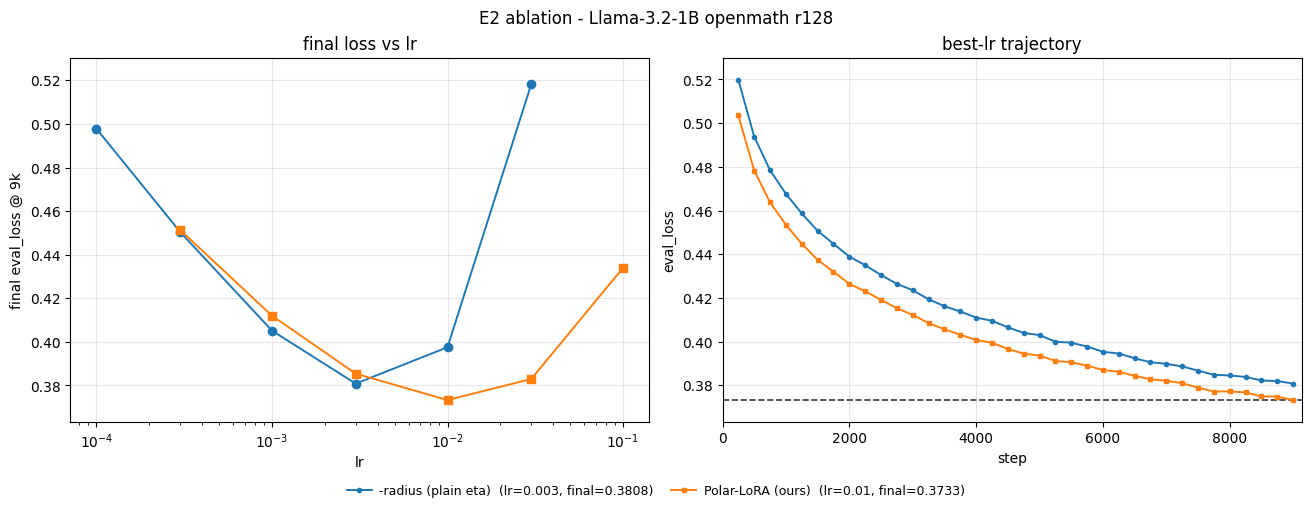

,variant,best_lr,final,delta,delta_sigma
0,-radius (plain eta),0.003,0.380835,0.007537,4.433624
1,Polar-LoRA (ours),0.010,0.373298,NaN,NaN


In [12]:
ablation_panel(128)

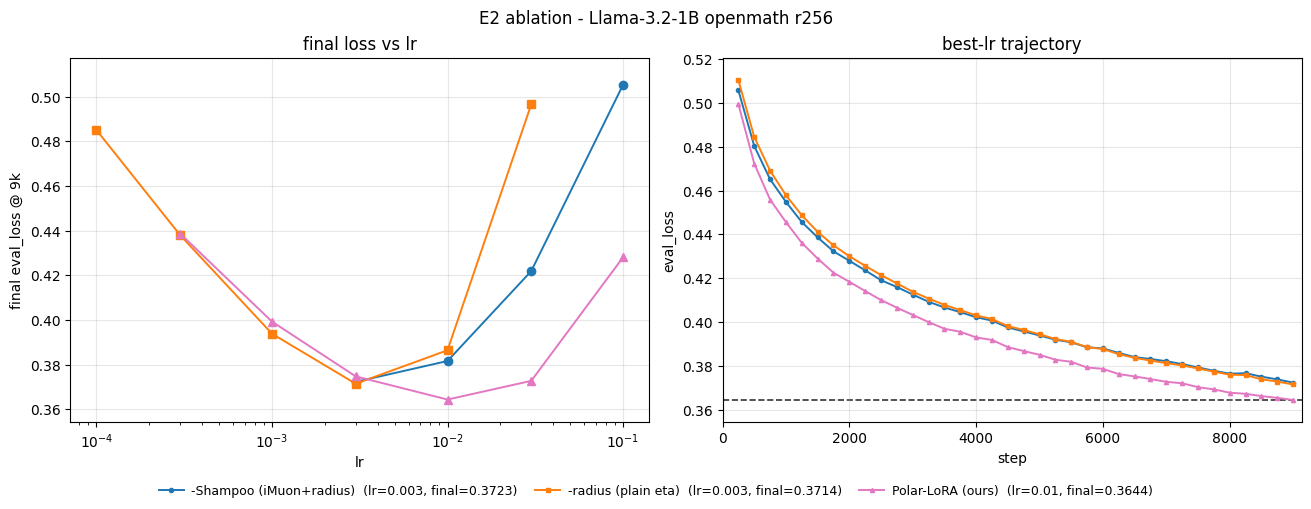

,variant,best_lr,final,delta,delta_sigma
0,-Shampoo (iMuon+radius),0.003,0.372290,0.007929,4.664240
1,-radius (plain eta),0.003,0.371442,0.007081,4.165229
2,Polar-LoRA (ours),0.010,0.364361,NaN,NaN


In [13]:
ablation_panel(256)

## E2 -radius transfer test - Llama-3.2-1B openmath r64/r128/r256

Does removing the operator-norm radius break lr-stability across rank? For each rank, final
eval loss vs lr: **protagonist** (radius on) vs **-radius** (radius off). If the protagonist's
optimum sits at a fixed lr across ranks while -radius's optimum shifts, the radius is what buys
the rank-stable lr. (No AdamW contrast - AdamW also transfers here; see the analysis notes.)

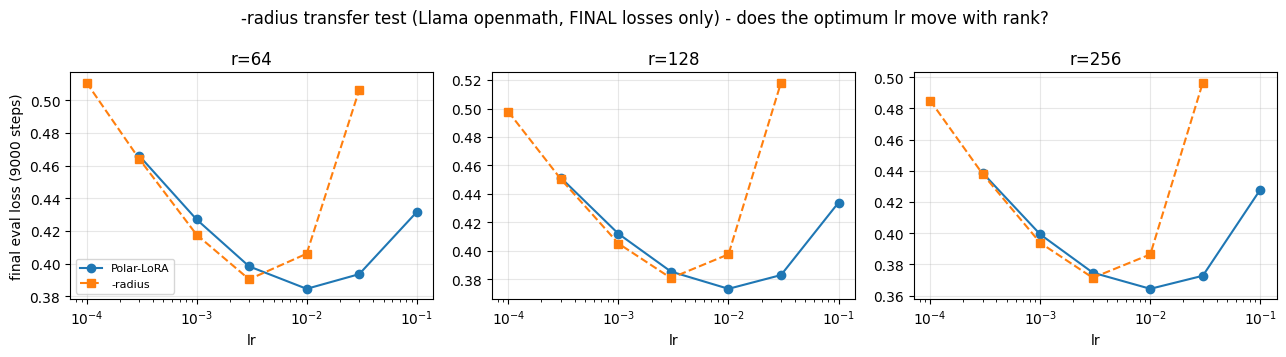

In [14]:
# Transfer test: FINAL-loss-vs-lr per rank, Polar-LoRA vs -radius. Only runs that reached the
# 9000-step horizon count -- a partial run would plot an early-step loss against final losses.
import numpy as np
RANKS=[64,128,256]; HORIZON=9000
def _final_by_lr(where, rank):
    runs=load_runs(where={**where,'lora_r':rank,'model_name':'meta-llama/Llama-3.2-1B',
                          'data_dir':(lambda d:'openmath' in str(d))}, warn_cross_commit=False)
    out={}
    for cfg,evs in runs:
        ev=[(e['step'],e['eval_loss']) for e in (evs or []) if e.get('eval_loss') is not None]
        if not ev or ev[-1][0] < HORIZON: continue   # final losses only (skip partial runs)
        lr=float(cfg.get('lr')); out[lr]=min(out.get(lr,9e9), ev[-1][1])
    return dict(sorted(out.items()))
fig,axes=plt.subplots(1,3,figsize=(13,3.6),sharey=False)
for ax,rank in zip(axes,RANKS):
    for label,where,mk in [('Polar-LoRA (diag-Shampoo)',PROTO,'o-'),('-radius',NORADIUS,'s--')]:
        d=_final_by_lr(where,rank)
        if d: ax.plot(list(d),list(d.values()),mk,label=label)
    ax.set_xscale('log'); ax.set_title(f'r={rank}'); ax.set_xlabel('lr'); ax.grid(alpha=.3)
    if rank==RANKS[0]: ax.set_ylabel('final eval loss (9000 steps)'); ax.legend(fontsize=8)
fig.suptitle('-radius transfer test (Llama openmath, FINAL losses only) - does the optimum lr move with rank?')
plt.tight_layout(); plt.show()

## 8B opc r256 — curvature/δ/lr lever investigation (in-flight)

Why is Polar-LoRA (diagonal) ~0.03 behind at 8B? One-variable probes vs the running base:
**KL-curv+ours** = dense-KL curvature with OUR settings (polar_express, ns8, δ=1e-4) — isolates
diagonal-vs-KL. **diag δ=1e-3** = damping probe. **KL-old** = the ns/δ=1e-3 KL that beats AdamW.
If KL-curv+ours tracks KL-old and beats the diagonal base, the curvature flavor is the lever
(diagonal insufficient at scale). Partial — re-run as the 8B probes fill in.

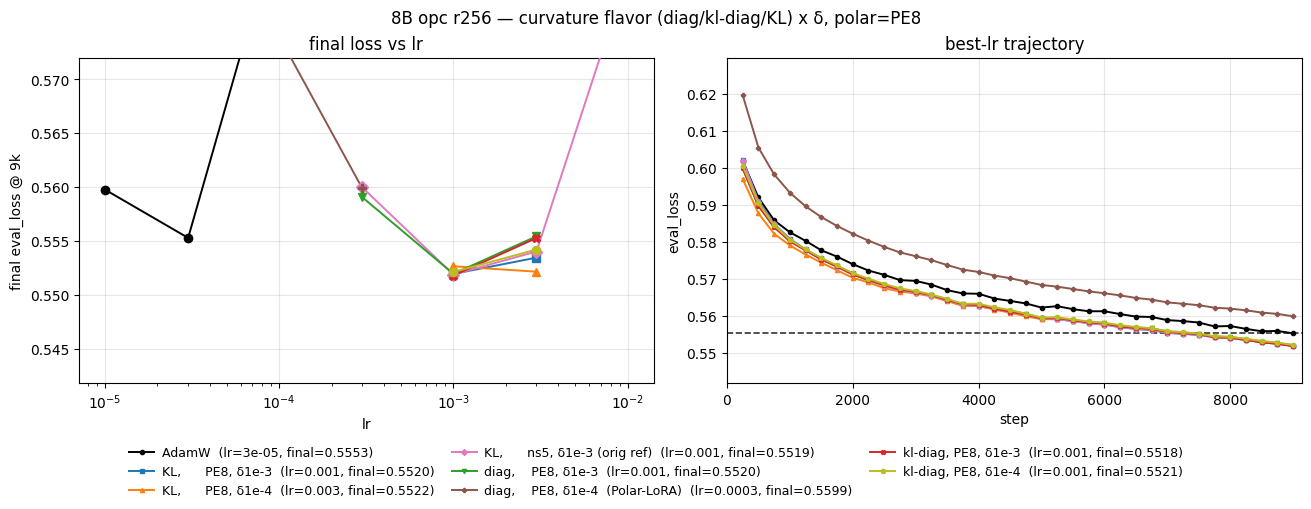

,variant,best_lr,final,delta,delta_sigma
0,AdamW,0.00003,0.555303,NaN,NaN
1,"KL, PE8, δ1e-3",0.00100,0.551960,-0.003343,-1.966651
2,"KL, PE8, δ1e-4",0.00300,0.552166,-0.003137,-1.845522
3,"KL, ns5, δ1e-3 (orig ref)",0.00100,0.551901,-0.003402,-2.001318
4,"diag, PE8, δ1e-3",0.00100,0.551968,-0.003335,-1.961799
5,"diag, PE8, δ1e-4 (Polar-LoRA)",0.00030,0.559903,0.004600,2.705632
6,"kl-diag, PE8, δ1e-3",0.00100,0.551804,-0.003499,-2.058307
7,"kl-diag, PE8, δ1e-4",0.00100,0.552135,-0.003168,-1.863814


In [15]:
# 8B levers. THREE curvature flavors (all polar=PE8) x δ, + AdamW + the ns5 KL ref.
#   diag    = plain per-coord energy D_in=Σg²            (kl_coupled=False) -> δ-FRAGILE
#   kl-diag = S_A^-1-coupled diagonal D_in=(gᵀS_A⁻¹g)ii   (kl_coupled=True, diag_metric)
#   KL      = dense small-side S_curv                     (kl_coupled=True, dense)  -> δ-robust
_d=lambda target:(lambda v: v is not None and abs(float(v)-target)<1e-9)
_8b=dict(model_name='meta-llama/Meta-Llama-3-8B', lora_r=256, data_dir=(lambda d:'opc' in str(d)))
_DIAG  =lambda dl:{**PROTO,'precond_delta':_d(dl)}
_KLDIAG=lambda dl:{'optimizer':'kl-diag-polar-lora','polar_method':'polar_express','precond_delta':_d(dl)}
_KL    =lambda dl:{'optimizer':'kl-shampoo-polar-lora','polar_method':'polar_express','precond_delta':_d(dl)}
_variants={
  'AdamW': ADAMW,
  'diag,    PE8, δ1e-4  (Polar-LoRA)': _DIAG(1e-4),
  'diag,    PE8, δ1e-3':               _DIAG(1e-3),
  'kl-diag, PE8, δ1e-4':               _KLDIAG(1e-4),
  'kl-diag, PE8, δ1e-3':               _KLDIAG(1e-3),
  'KL,      PE8, δ1e-4':               _KL(1e-4),
  'KL,      PE8, δ1e-3':               _KL(1e-3),
  'KL,      ns5, δ1e-3 (orig ref)':    {'optimizer':'kl-shampoo-polar-lora','polar_method':'ns'},
}
fig,_t,sdf_8b = compare_variants_figure(
  _variants, common_where=_8b, ref_label='AdamW',
  logs_root=str(ROOT/'logs'), sigma_ref=SIGMA, max_steps=9000,
  allow_partial=True, allow_custom_labels=True,
  suptitle='8B opc r256 — curvature flavor (diag/kl-diag/KL) x δ, polar=PE8')
plt.show()
sdf_8b

## Sanity gate (pre-rerun) — kl-diag ≡ diag-shampoo at 1B?

Matched-config check before committing the kl-diag full rerun. kl-diag-polar PE8 + Nesterov + β1=0.9 + δ=1e-4 at **OLMo opc r64**, every knob matched to the existing diag-shampoo PE8+Nesterov baseline (best **0.7562** @ lr0.03), so the *only* difference is the diag→kl coupling. Within ~1σ (σ at r64 ≈ 0.0007) ⇒ coupling inert at 1B ⇒ green-light the rerun. kl-diag run `6498391`, in-flight (`allow_partial`).

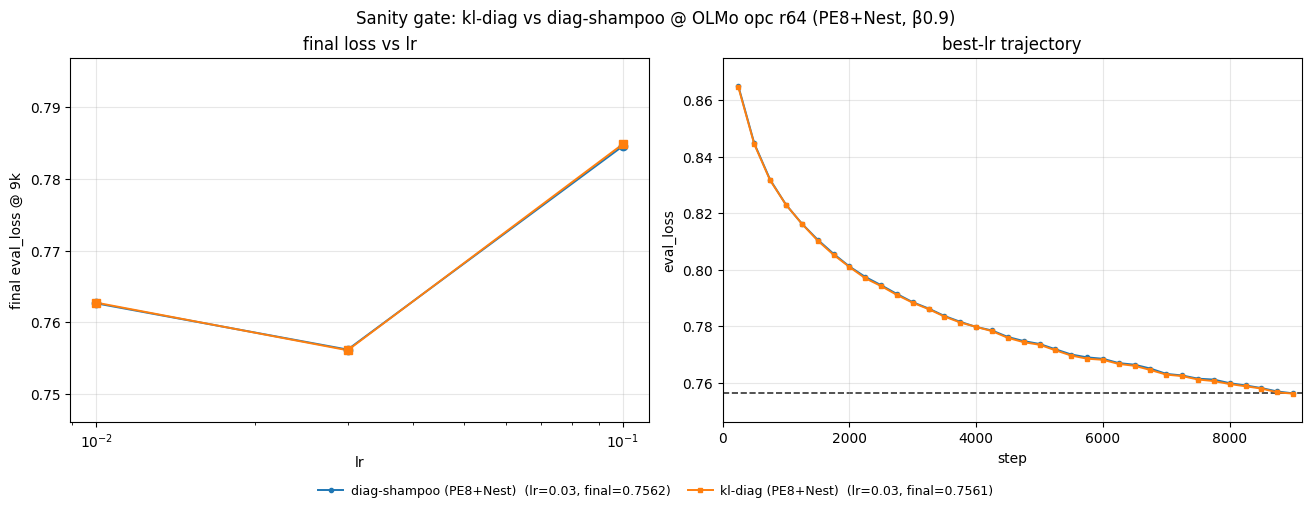

,variant,best_lr,final,delta,delta_sigma
0,diag-shampoo (PE8+Nest),0.03,0.756170,NaN,NaN
1,kl-diag (PE8+Nest),0.03,0.756076,-0.000094,-0.134673


In [16]:
# Sanity gate: kl-diag vs the diag-shampoo PE8+Nesterov baseline @ OLMo opc r64, both β1=0.9
# (r64-OLMo-opc is NOT a paper cell, so β is irrelevant here; β0.9 isolates ONLY the diag→kl
# coupling). The polar_express filter excludes the historical ns5 kl-diag runs. Run 6498391 is
# in-flight: kl-diag shows in the TRAJECTORY panel (partial, step-matched); the final-loss
# table lists it only once it reaches step 9000. sigma_ref = r64 multiseed noise (0.0007).
_sanity_common = dict(model_name='allenai/OLMo-2-0425-1B', lora_r=64,
                      data_dir=(lambda d: 'opc' in str(d)))
_DIAG_PE8N   = {'optimizer': 'diag-shampoo-polar-lora', 'cw_nesterov': True,
                'polar_method': 'polar_express', 'cw_no_radius': False, 'cw_no_diag_curv': False}
_KLDIAG_PE8N = {**_DIAG_PE8N, 'optimizer': 'kl-diag-polar-lora'}
fig, _t, sdf_sanity = compare_variants_figure(
    {'diag-shampoo (PE8+Nest)': _DIAG_PE8N, 'kl-diag (PE8+Nest)': _KLDIAG_PE8N},
    common_where=_sanity_common, ref_label='diag-shampoo (PE8+Nest)',
    logs_root=str(ROOT / 'logs'), sigma_ref=0.0007, max_steps=9000,
    allow_partial=True, target_label=None, allow_custom_labels=True,
    suptitle='Sanity gate: kl-diag vs diag-shampoo @ OLMo opc r64 (PE8+Nest, β0.9)')
plt.show()
sdf_sanity

## Scoped β₁ selection — kl-diag-polar-lora @ OLMo opc r256 (β=0.9 vs 0.95)

Post `beta1`-forwarding-fix (`c76ebd2`): the protagonist now actually runs `--beta1` (pre-fix the curvature-whiten branch hardcoded 0.9). Best held-out per β locks the β for the full rerun (tie → 0.95). **β=0.9 wins** (0.7357 @ lr0.03 vs β=0.95 0.7377 @ lr0.01); note the best lr shifts with β.

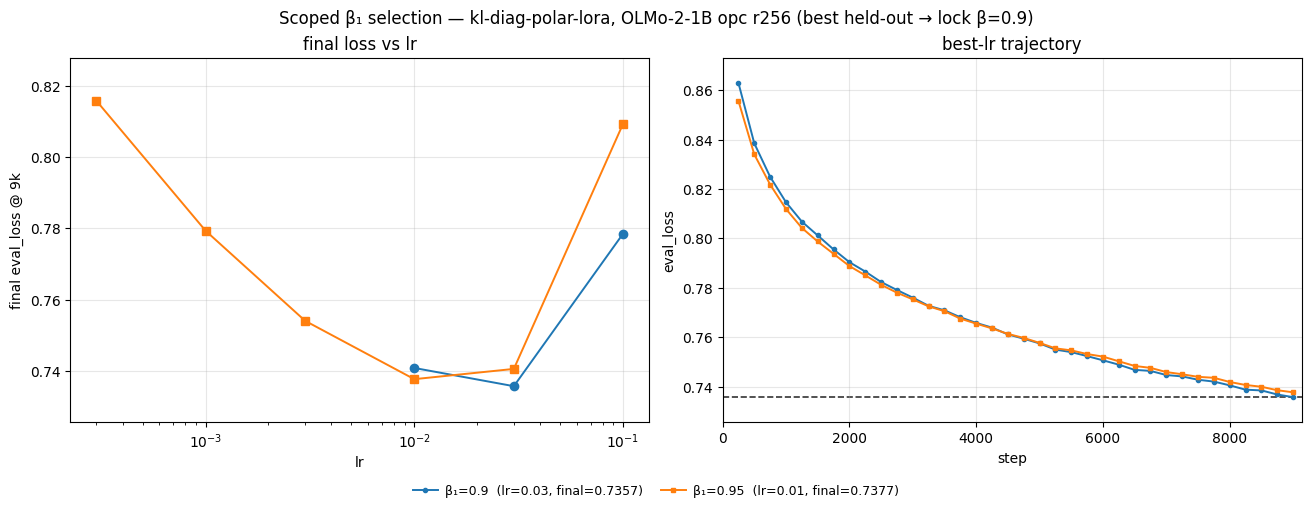

,variant,best_lr,final,delta,delta_sigma
0,β₁=0.9,0.03,0.735741,NaN,NaN
1,β₁=0.95,0.01,0.737709,0.001968,1.157588


In [17]:
# Scoped β₁ selection — kl-diag-polar-lora @ OLMo opc r256, β₁=0.9 vs 0.95.
# Post beta1-forwarding-fix (c76ebd2): the protagonist now actually runs --beta1 (pre-fix
# the cw branch hardcoded 0.9). Best held-out per β locks β for the full rerun (tie -> 0.95).
# Result: β=0.9 wins (0.7357 @ lr0.03 vs β=0.95 0.7377 @ lr0.01); best lr shifts with β.
_beta_common = dict(optimizer='kl-diag-polar-lora', model_name='allenai/OLMo-2-0425-1B',
                    lora_r=256, data_dir=(lambda d: 'opc' in str(d)), precond_delta=1e-4)
fig, _t, sdf = compare_variants_figure(
    {'β₁=0.9': {'beta1': 0.9}, 'β₁=0.95': {'beta1': 0.95}},
    common_where=_beta_common, ref_label='β₁=0.9',
    logs_root=str(ROOT / 'logs'), sigma_ref=SIGMA, max_steps=9000,
    target_label=None, allow_custom_labels=True,
    suptitle='Scoped β₁ selection — kl-diag-polar-lora, OLMo-2-1B opc r256 (best held-out → lock β=0.9)',
)
plt.show()
sdf

## Stage-1: gram_ns no-degradation sanity (monitor)

Overlays the 3 in-flight gram_ns sanity runs on their existing eigh baselines. Re-run the cell below to refresh.

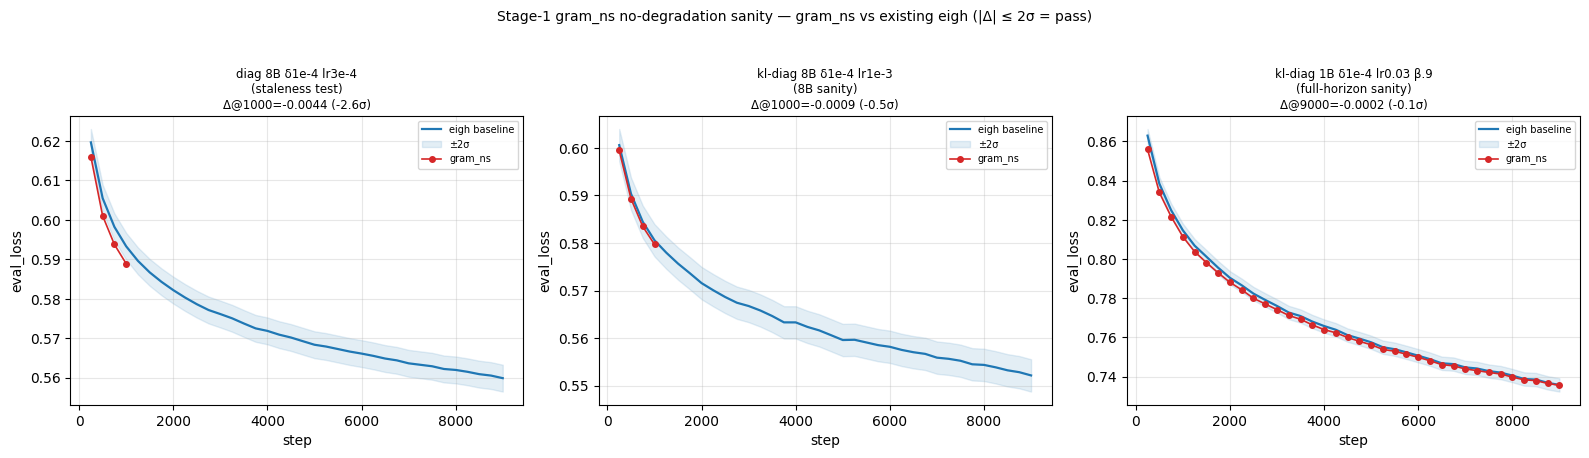

In [20]:
# === Stage-1 gram_ns SANITY MONITOR — gram_ns (bench_polar_out logs) vs existing eigh baselines ===
# Re-run anytime to refresh as the 3 sanity jobs land.
# gram_ns logs: <ROOT>/bench_polar_out/gramns_sanity/<cell>/log_0.out (self-contained; read directly).
# Pass = |Δ(gram_ns - eigh)| <= 2σ at every step (no degradation). For the diag staleness cell, a
# NEGATIVE Δ (gram_ns below eigh, toward kl-diag/KL) would mean the stale eigenbasis was the cause.
import json
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

_GDIR = ROOT / "bench_polar_out" / "gramns_sanity"   # ROOT-anchored — notebook CWD is paper/

def _read_gramns(path):
    evs = []
    try:
        for line in open(path, errors='ignore'):
            try: d = json.loads(line)
            except Exception: continue
            if d.get("event") == "eval" and isinstance(d.get("eval_loss"), (int, float)):
                evs.append((d["step"], d["eval_loss"]))
    except FileNotFoundError:
        pass
    return sorted(evs)

def _eigh_traj(where):
    best = None
    for cfg, events in load_runs(where=where, warn_cross_commit=False):
        evs = sorted((e["step"], e["eval_loss"]) for e in events
                     if e.get("event") == "eval" and isinstance(e.get("eval_loss"), (int, float)))
        if evs and (best is None or len(evs) > len(best)):
            best = evs
    return best or []

_SAN = [
 ("diag 8B δ1e-4 lr3e-4\n(staleness test)", _GDIR / "diag" / "log_0.out",
  {"optimizer": "diag-shampoo-polar-lora", "lora_r": 256, "precond_delta": 1e-4, "beta1": 0.95, "seed": 0,
   "lr": lambda v: abs(float(v)-3e-4) < 1e-9, "model_name": lambda m: "8B" in str(m), "data_dir": lambda d: "opc" in str(d)}),
 ("kl-diag 8B δ1e-4 lr1e-3\n(8B sanity)", _GDIR / "kldiag" / "log_0.out",
  {"optimizer": "kl-diag-polar-lora", "lora_r": 256, "precond_delta": 1e-4, "beta1": 0.95, "seed": 0,
   "lr": lambda v: abs(float(v)-1e-3) < 1e-9, "model_name": lambda m: "8B" in str(m), "data_dir": lambda d: "opc" in str(d)}),
 ("kl-diag 1B δ1e-4 lr0.03 β.9\n(full-horizon sanity)", _GDIR / "kldiag_1b" / "log_0.out",
  {"optimizer": "kl-diag-polar-lora", "lora_r": 256, "precond_delta": 1e-4, "beta1": 0.9, "seed": 0,
   "lr": lambda v: abs(float(v)-0.03) < 1e-9, "model_name": lambda m: "OLMo" in str(m), "data_dir": lambda d: "opc" in str(d)}),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, (label, logp, where) in zip(axes, _SAN):
    eigh = _eigh_traj(where)
    gram = _read_gramns(logp)
    if eigh:
        es, el = zip(*eigh)
        ax.plot(es, el, '-', color='C0', lw=1.6, label='eigh baseline')
        ax.fill_between(es, [v - 2*SIGMA for v in el], [v + 2*SIGMA for v in el], color='C0', alpha=0.12, label='±2σ')
    title = label
    if gram:
        gs, gl = zip(*gram)
        ax.plot(gs, gl, 'o-', color='C3', ms=4, lw=1.2, label='gram_ns')
        ed = dict(eigh); common = [s for s in gs if s in ed]
        if common:
            s = common[-1]; d = dict(gram)[s] - ed[s]
            title = f"{label}\nΔ@{s}={d:+.4f} ({d/SIGMA:+.1f}σ)"
    else:
        title = f"{label}\n(awaiting gram_ns evals)"
    ax.set_title(title, fontsize=8.5)
    ax.set_xlabel('step'); ax.set_ylabel('eval_loss'); ax.grid(alpha=0.3); ax.legend(fontsize=7)
fig.suptitle('Stage-1 gram_ns no-degradation sanity — gram_ns vs existing eigh (|Δ| ≤ 2σ = pass)', y=1.03, fontsize=10)
plt.tight_layout(); plt.show()
